In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import MNIST
from torchvision import transforms
from scipy.stats import wasserstein_distance
import torchvision

In [2]:
# 设置随机种子以获得可重复结果
torch.manual_seed(42)
np.random.seed(42)

# 检查GPU可用性
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 加载MNIST数据集
transform = transforms.Compose([
    transforms.ToTensor(),
])

# 加载训练和测试数据
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=60, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=60, shuffle=False)

Using device: cuda:0


Training data shapes: X=torch.Size([10000, 1, 28, 28]), y=torch.Size([10000])
Testing data shapes: X=torch.Size([60, 1, 28, 28]), y=torch.Size([60])


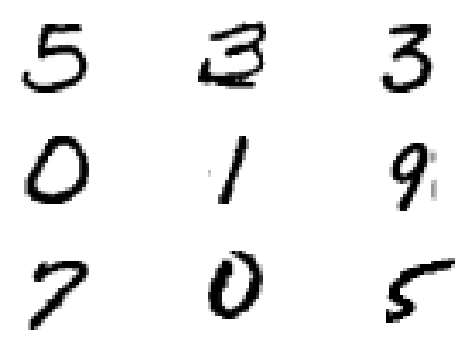

In [3]:
# 获取一些样本数据以进行可视化
trainX = []
trainY = []

for images, labels in train_loader:
    trainX.append(images)
    trainY.append(labels)
    if len(trainX) * images.shape[0] >= 10000:  # 只取前10000个图像
        break

trainX = torch.cat(trainX, dim=0)[:10000]  # 取前10000个图像
trainY = torch.cat(trainY, dim=0)[:10000]  # 取前10000个标签

print('Training data shapes: X=%s, y=%s' % (trainX.shape, trainY.shape))
testX = next(iter(test_loader))[0]
testY = next(iter(test_loader))[1]
print('Testing data shapes: X=%s, y=%s' % (testX.shape, testY.shape))

# 可视化一些训练图像
for k in range(1):  # 只显示一组图像，避免显示过多
    plt.figure(figsize=(9, 6))
    for j in range(9):
        i = np.random.randint(0, 10000)
        plt.subplot(3, 3, j+1)
        plt.imshow(trainX[i][0], cmap='gray_r')  # 索引[0]获取通道维度
        plt.axis('off')
    plt.show()


In [4]:
# 定义生成器网络
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 64),
            nn.ReLU(True),
            nn.Linear(64, 28*28),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.main(x)
        return x.view(-1, 1, 28, 28)  # 调整形状为 (batch_size, 1, 28, 28)

# 定义判别器网络
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.sigmoid = nn.Sigmoid()
     
    def forward(self, x):
        output = self.main(x)
        output = self.sigmoid(output / 0.1)
        return output

In [5]:
# 初始化网络
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# 打印网络结构
print(generator)
print(discriminator)

# 定义损失函数和优化器
criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

# 生成随机噪声
#def get_random_noise(batch_size, noise_size):
#    return torch.randn(batch_size, noise_size, device=device)

# 获取假样本
def get_fake_samples(generator, batch_size):
    random_noise_batch = torch.randn(batch_size, 100, device=device)  # 生成随机噪声向量
    fake_samples = generator(random_noise_batch)
    return fake_samples

# 获取真实样本
def get_real_samples(batch_size):
    random_indices = np.random.choice(range(len(trainX)), size=batch_size)
    real_images = trainX[random_indices].to(device)
    return real_images

# 展示生成器结果
def show_generator_results(generator):
    generator.eval()  # 设置为评估模式
    fake_samples = get_fake_samples(generator, 9)  # 获取假样本
    fake_samples = fake_samples.detach().cpu()  # 将张量从GPU转移到CPU
    fake_samples = fake_samples.numpy()  # 转换为NumPy数组
    # 调整图像形状以适合imshow显示
    # 假设图像是单通道的（例如MNIST数据集），形状为 (batch_size, 1, height, width)
    fake_samples = fake_samples.squeeze(1)  # 去掉通道维度
    plt.figure(figsize=(9, 6))
    for j in range(9):
        plt.subplot(3, 3, j+1)
        plt.imshow(fake_samples[j], cmap='gray_r')  # 显示图像
        plt.axis('off')
    plt.show()
    generator.train()  # 恢复为训练模式

Generator(
  (main): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=784, bias=True)
    (3): Sigmoid()
  )
)
Discriminator(
  (main): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
  (sigmoid): Sigmoid()
)


In [6]:
# 训练参数
epochs = 500
batch_size = 60
steps = 50  # 在每个epoch中的训练步数
#noise_size = 2
#noise_std = 0.05
#noise_std_min = 0.01
#noise_std_max = 0.2
#noise_increase_factor = 1.05
#noise_decrease_factor = 0.95
#noise_change_threshold = 1e-3

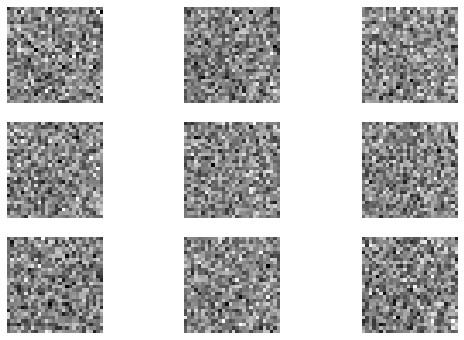

Epoch:0, D-Loss:0.086, D-Acc:100.000, G-Loss:5.359
Epoch:1, D-Loss:0.035, D-Acc:100.000, G-Loss:6.130
Epoch:2, D-Loss:0.010, D-Acc:100.000, G-Loss:6.914
Epoch:3, D-Loss:0.010, D-Acc:100.000, G-Loss:7.292
Epoch:4, D-Loss:0.003, D-Acc:100.000, G-Loss:8.230


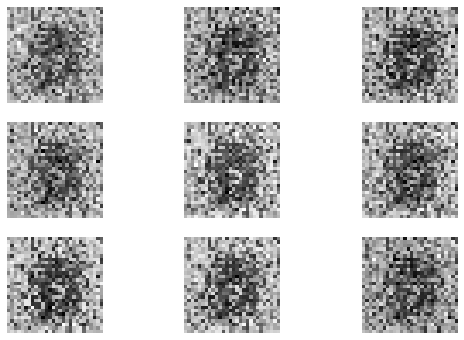

Epoch:5, D-Loss:0.013, D-Acc:100.000, G-Loss:8.273
Epoch:6, D-Loss:0.011, D-Acc:100.000, G-Loss:9.102
Epoch:7, D-Loss:0.005, D-Acc:100.000, G-Loss:9.682
Epoch:8, D-Loss:0.005, D-Acc:100.000, G-Loss:10.579
Epoch:9, D-Loss:0.003, D-Acc:100.000, G-Loss:9.984


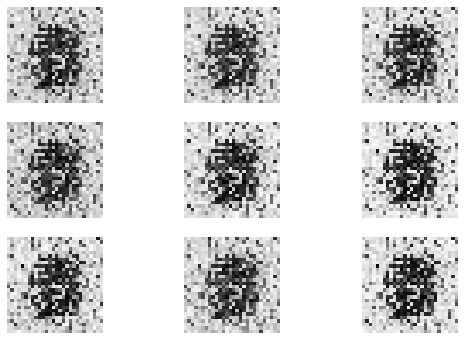

Epoch:10, D-Loss:0.004, D-Acc:100.000, G-Loss:9.320
Epoch:11, D-Loss:0.005, D-Acc:100.000, G-Loss:9.751
Epoch:12, D-Loss:0.009, D-Acc:100.000, G-Loss:10.275
Epoch:13, D-Loss:0.014, D-Acc:100.000, G-Loss:9.906
Epoch:14, D-Loss:0.014, D-Acc:100.000, G-Loss:9.304


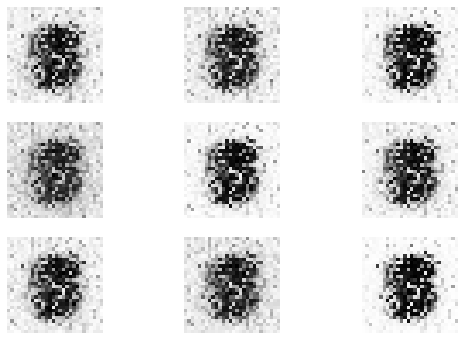

Epoch:15, D-Loss:0.018, D-Acc:100.000, G-Loss:10.278
Epoch:16, D-Loss:0.031, D-Acc:100.000, G-Loss:8.486
Epoch:17, D-Loss:0.029, D-Acc:100.000, G-Loss:7.701
Epoch:18, D-Loss:0.039, D-Acc:100.000, G-Loss:6.346
Epoch:19, D-Loss:0.077, D-Acc:100.000, G-Loss:6.610


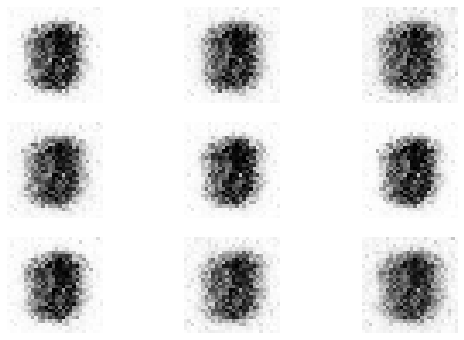

Epoch:20, D-Loss:0.095, D-Acc:100.000, G-Loss:5.110
Epoch:21, D-Loss:0.192, D-Acc:98.333, G-Loss:4.672
Epoch:22, D-Loss:0.114, D-Acc:100.000, G-Loss:4.369
Epoch:23, D-Loss:0.146, D-Acc:96.667, G-Loss:4.974
Epoch:24, D-Loss:0.097, D-Acc:100.000, G-Loss:4.710


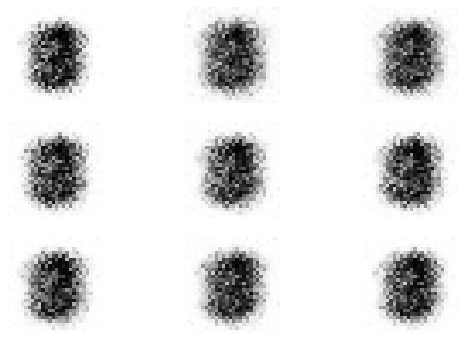

Epoch:25, D-Loss:0.194, D-Acc:98.333, G-Loss:4.233
Epoch:26, D-Loss:0.068, D-Acc:100.000, G-Loss:4.296
Epoch:27, D-Loss:0.071, D-Acc:100.000, G-Loss:4.933
Epoch:28, D-Loss:0.073, D-Acc:100.000, G-Loss:4.697
Epoch:29, D-Loss:0.042, D-Acc:100.000, G-Loss:4.549


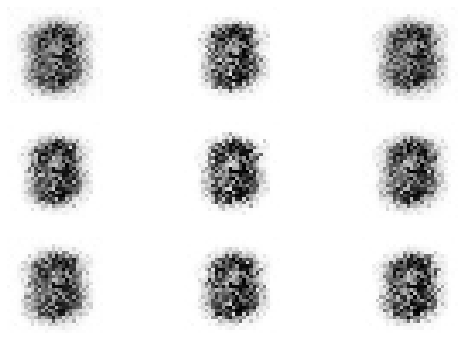

Epoch:30, D-Loss:0.031, D-Acc:100.000, G-Loss:5.064
Epoch:31, D-Loss:0.047, D-Acc:100.000, G-Loss:4.574
Epoch:32, D-Loss:0.036, D-Acc:100.000, G-Loss:4.627
Epoch:33, D-Loss:0.034, D-Acc:100.000, G-Loss:4.838
Epoch:34, D-Loss:0.027, D-Acc:100.000, G-Loss:4.792


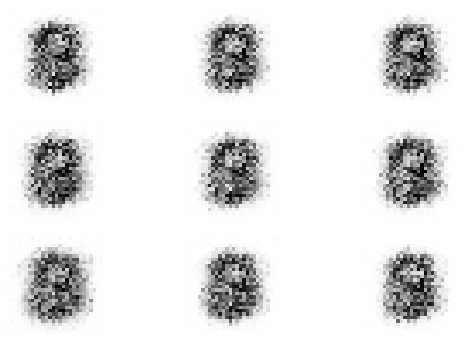

Epoch:35, D-Loss:0.057, D-Acc:100.000, G-Loss:4.597
Epoch:36, D-Loss:0.025, D-Acc:100.000, G-Loss:4.376
Epoch:37, D-Loss:0.024, D-Acc:100.000, G-Loss:4.693
Epoch:38, D-Loss:0.014, D-Acc:100.000, G-Loss:5.020
Epoch:39, D-Loss:0.027, D-Acc:100.000, G-Loss:5.020


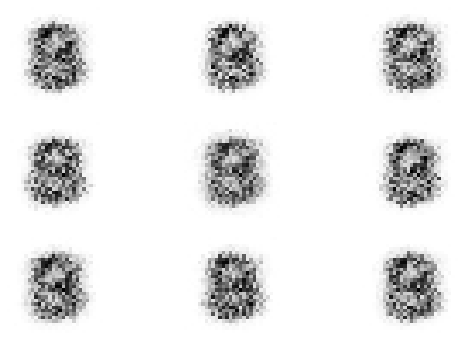

Epoch:40, D-Loss:0.057, D-Acc:100.000, G-Loss:4.851
Epoch:41, D-Loss:0.017, D-Acc:100.000, G-Loss:4.951
Epoch:42, D-Loss:0.032, D-Acc:100.000, G-Loss:4.406
Epoch:43, D-Loss:0.058, D-Acc:100.000, G-Loss:4.217
Epoch:44, D-Loss:0.107, D-Acc:98.333, G-Loss:4.072


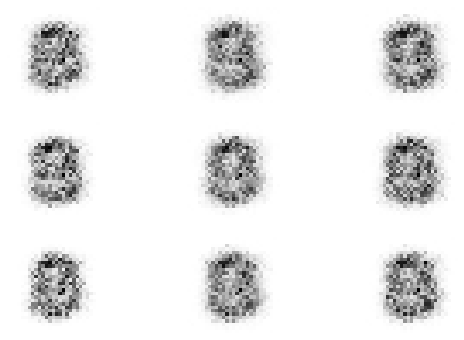

Epoch:45, D-Loss:0.063, D-Acc:100.000, G-Loss:4.380
Epoch:46, D-Loss:0.172, D-Acc:98.333, G-Loss:4.068
Epoch:47, D-Loss:0.092, D-Acc:98.333, G-Loss:4.009
Epoch:48, D-Loss:0.090, D-Acc:98.333, G-Loss:4.030
Epoch:49, D-Loss:0.071, D-Acc:98.333, G-Loss:3.970


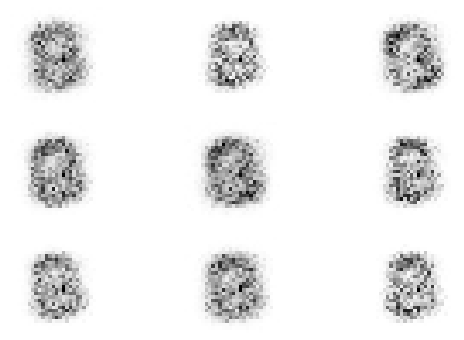

Epoch:50, D-Loss:0.081, D-Acc:98.333, G-Loss:4.074
Epoch:51, D-Loss:0.098, D-Acc:98.333, G-Loss:3.839
Epoch:52, D-Loss:0.088, D-Acc:100.000, G-Loss:3.413
Epoch:53, D-Loss:0.188, D-Acc:98.333, G-Loss:3.270
Epoch:54, D-Loss:0.214, D-Acc:98.333, G-Loss:2.913


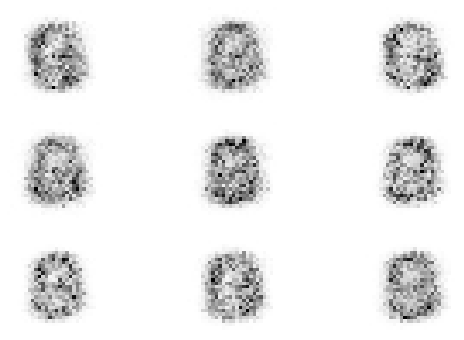

Epoch:55, D-Loss:0.053, D-Acc:100.000, G-Loss:3.089
Epoch:56, D-Loss:0.240, D-Acc:98.333, G-Loss:3.046
Epoch:57, D-Loss:0.159, D-Acc:98.333, G-Loss:2.645
Epoch:58, D-Loss:0.078, D-Acc:100.000, G-Loss:3.249
Epoch:59, D-Loss:0.199, D-Acc:96.667, G-Loss:3.172


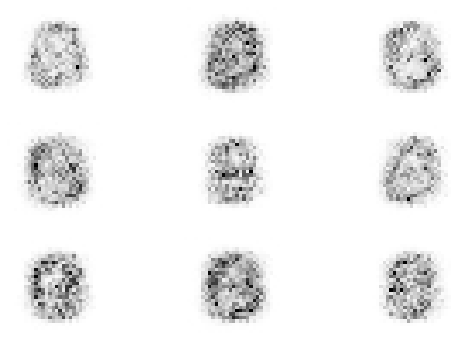

Epoch:60, D-Loss:0.154, D-Acc:98.333, G-Loss:2.549
Epoch:61, D-Loss:0.099, D-Acc:100.000, G-Loss:2.901
Epoch:62, D-Loss:0.099, D-Acc:100.000, G-Loss:2.867
Epoch:63, D-Loss:0.151, D-Acc:98.333, G-Loss:2.912
Epoch:64, D-Loss:0.074, D-Acc:100.000, G-Loss:3.362


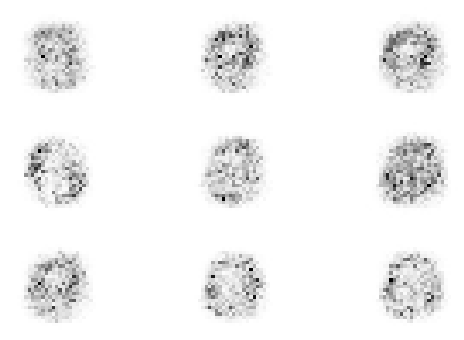

Epoch:65, D-Loss:0.135, D-Acc:98.333, G-Loss:3.255
Epoch:66, D-Loss:0.096, D-Acc:98.333, G-Loss:3.211
Epoch:67, D-Loss:0.055, D-Acc:100.000, G-Loss:3.145
Epoch:68, D-Loss:0.058, D-Acc:100.000, G-Loss:3.172
Epoch:69, D-Loss:0.167, D-Acc:96.667, G-Loss:3.343


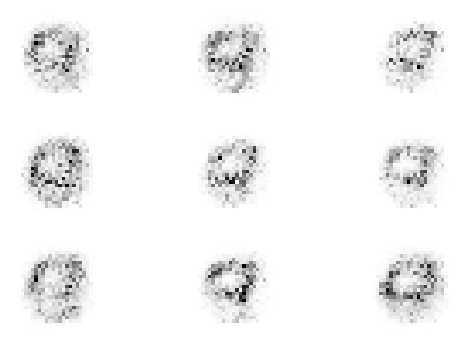

Epoch:70, D-Loss:0.035, D-Acc:100.000, G-Loss:3.413
Epoch:71, D-Loss:0.073, D-Acc:100.000, G-Loss:3.282
Epoch:72, D-Loss:0.077, D-Acc:98.333, G-Loss:3.192
Epoch:73, D-Loss:0.070, D-Acc:100.000, G-Loss:2.976
Epoch:74, D-Loss:0.108, D-Acc:98.333, G-Loss:3.139


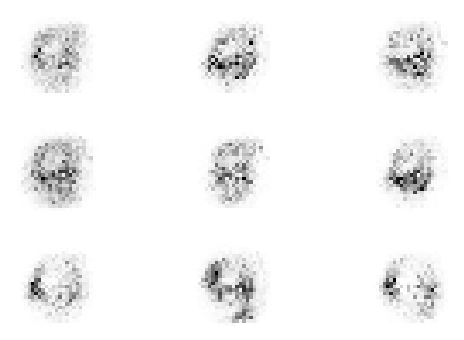

Epoch:75, D-Loss:0.068, D-Acc:100.000, G-Loss:3.020
Epoch:76, D-Loss:0.094, D-Acc:100.000, G-Loss:3.417
Epoch:77, D-Loss:0.095, D-Acc:98.333, G-Loss:3.419
Epoch:78, D-Loss:0.044, D-Acc:100.000, G-Loss:3.610
Epoch:79, D-Loss:0.049, D-Acc:100.000, G-Loss:4.000


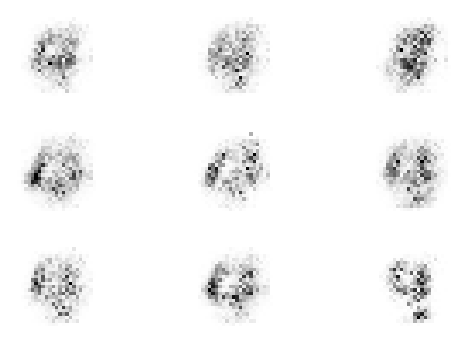

Epoch:80, D-Loss:0.070, D-Acc:100.000, G-Loss:3.763
Epoch:81, D-Loss:0.049, D-Acc:100.000, G-Loss:3.681
Epoch:82, D-Loss:0.063, D-Acc:100.000, G-Loss:3.763
Epoch:83, D-Loss:0.034, D-Acc:100.000, G-Loss:3.791
Epoch:84, D-Loss:0.049, D-Acc:100.000, G-Loss:3.767


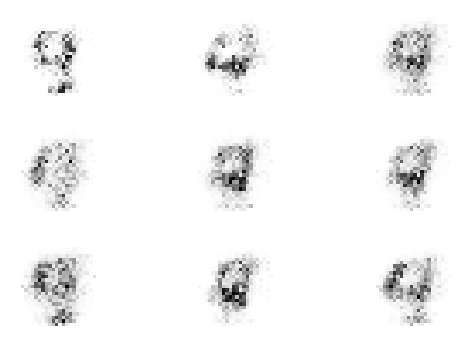

Epoch:85, D-Loss:0.045, D-Acc:100.000, G-Loss:3.596
Epoch:86, D-Loss:0.056, D-Acc:100.000, G-Loss:3.686
Epoch:87, D-Loss:0.054, D-Acc:100.000, G-Loss:3.693
Epoch:88, D-Loss:0.103, D-Acc:100.000, G-Loss:3.688
Epoch:89, D-Loss:0.098, D-Acc:100.000, G-Loss:3.453


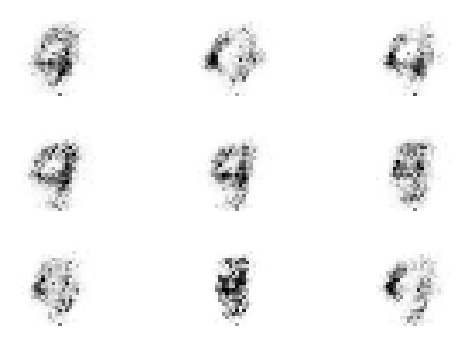

Epoch:90, D-Loss:0.065, D-Acc:100.000, G-Loss:3.703
Epoch:91, D-Loss:0.138, D-Acc:98.333, G-Loss:3.324
Epoch:92, D-Loss:0.155, D-Acc:98.333, G-Loss:3.599
Epoch:93, D-Loss:0.100, D-Acc:98.333, G-Loss:3.155
Epoch:94, D-Loss:0.066, D-Acc:100.000, G-Loss:4.355


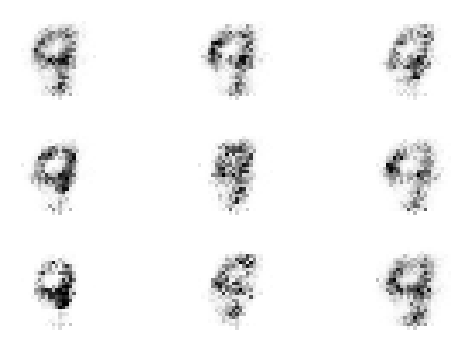

Epoch:95, D-Loss:0.109, D-Acc:98.333, G-Loss:4.416
Epoch:96, D-Loss:0.044, D-Acc:100.000, G-Loss:3.928
Epoch:97, D-Loss:0.080, D-Acc:98.333, G-Loss:3.963
Epoch:98, D-Loss:0.080, D-Acc:98.333, G-Loss:4.363
Epoch:99, D-Loss:0.029, D-Acc:100.000, G-Loss:4.293


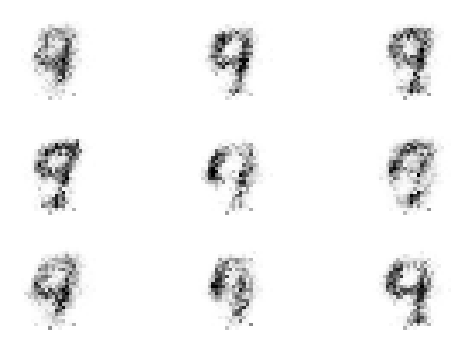

Epoch:100, D-Loss:0.040, D-Acc:100.000, G-Loss:3.845
Epoch:101, D-Loss:0.147, D-Acc:96.667, G-Loss:4.551
Epoch:102, D-Loss:0.053, D-Acc:100.000, G-Loss:3.657
Epoch:103, D-Loss:0.082, D-Acc:100.000, G-Loss:4.059
Epoch:104, D-Loss:0.161, D-Acc:95.000, G-Loss:4.160


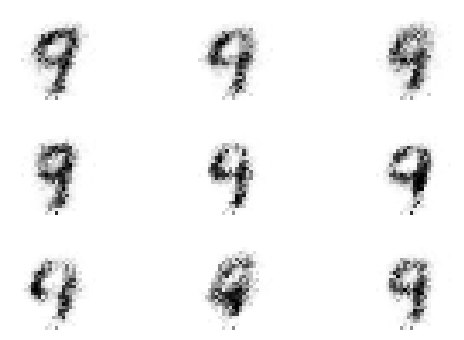

Epoch:105, D-Loss:0.128, D-Acc:98.333, G-Loss:4.129
Epoch:106, D-Loss:0.038, D-Acc:100.000, G-Loss:4.416
Epoch:107, D-Loss:0.081, D-Acc:98.333, G-Loss:4.422
Epoch:108, D-Loss:0.040, D-Acc:100.000, G-Loss:4.100
Epoch:109, D-Loss:0.129, D-Acc:96.667, G-Loss:4.254


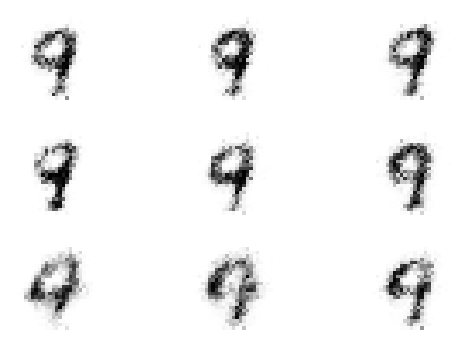

Epoch:110, D-Loss:0.059, D-Acc:100.000, G-Loss:3.905
Epoch:111, D-Loss:0.080, D-Acc:98.333, G-Loss:3.922
Epoch:112, D-Loss:0.076, D-Acc:98.333, G-Loss:4.417
Epoch:113, D-Loss:0.131, D-Acc:96.667, G-Loss:3.520
Epoch:114, D-Loss:0.059, D-Acc:100.000, G-Loss:4.391


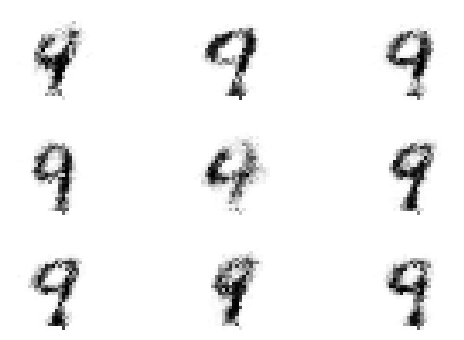

Epoch:115, D-Loss:0.091, D-Acc:96.667, G-Loss:4.231
Epoch:116, D-Loss:0.149, D-Acc:96.667, G-Loss:3.666
Epoch:117, D-Loss:0.081, D-Acc:96.667, G-Loss:4.246
Epoch:118, D-Loss:0.078, D-Acc:98.333, G-Loss:4.764
Epoch:119, D-Loss:0.161, D-Acc:96.667, G-Loss:3.794


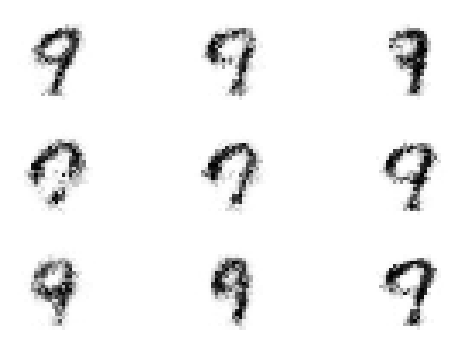

Epoch:120, D-Loss:0.124, D-Acc:98.333, G-Loss:3.857
Epoch:121, D-Loss:0.165, D-Acc:98.333, G-Loss:3.266
Epoch:122, D-Loss:0.088, D-Acc:98.333, G-Loss:4.153
Epoch:123, D-Loss:0.175, D-Acc:98.333, G-Loss:3.623
Epoch:124, D-Loss:0.117, D-Acc:100.000, G-Loss:3.466


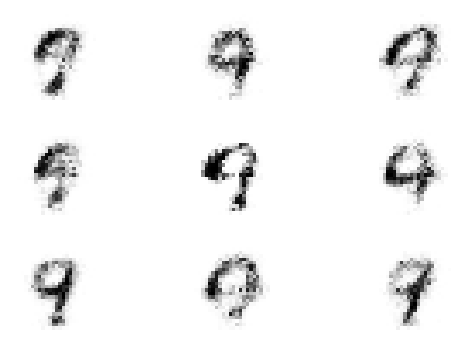

Epoch:125, D-Loss:0.079, D-Acc:100.000, G-Loss:3.416
Epoch:126, D-Loss:0.229, D-Acc:96.667, G-Loss:3.486
Epoch:127, D-Loss:0.052, D-Acc:100.000, G-Loss:4.337
Epoch:128, D-Loss:0.180, D-Acc:95.000, G-Loss:3.503
Epoch:129, D-Loss:0.105, D-Acc:100.000, G-Loss:4.507


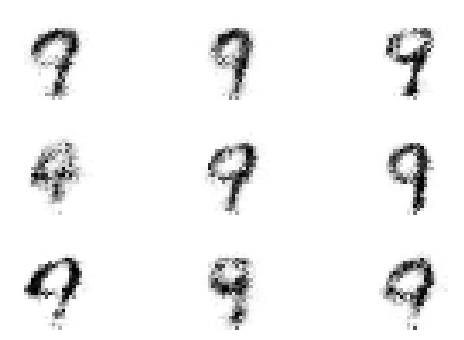

Epoch:130, D-Loss:0.168, D-Acc:96.667, G-Loss:4.102
Epoch:131, D-Loss:0.168, D-Acc:98.333, G-Loss:3.920
Epoch:132, D-Loss:0.262, D-Acc:96.667, G-Loss:3.427
Epoch:133, D-Loss:0.082, D-Acc:98.333, G-Loss:3.339
Epoch:134, D-Loss:0.218, D-Acc:96.667, G-Loss:3.456


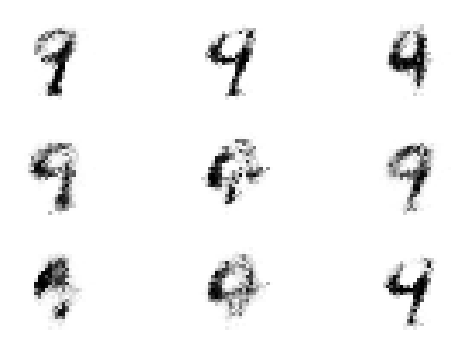

Epoch:135, D-Loss:0.098, D-Acc:98.333, G-Loss:3.732
Epoch:136, D-Loss:0.133, D-Acc:98.333, G-Loss:3.947
Epoch:137, D-Loss:0.286, D-Acc:95.000, G-Loss:3.011
Epoch:138, D-Loss:0.138, D-Acc:98.333, G-Loss:3.807
Epoch:139, D-Loss:0.098, D-Acc:98.333, G-Loss:3.497


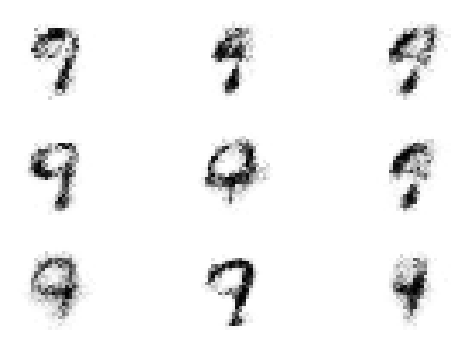

Epoch:140, D-Loss:0.184, D-Acc:98.333, G-Loss:2.911
Epoch:141, D-Loss:0.162, D-Acc:95.000, G-Loss:4.072
Epoch:142, D-Loss:0.119, D-Acc:98.333, G-Loss:3.778
Epoch:143, D-Loss:0.254, D-Acc:95.000, G-Loss:3.041
Epoch:144, D-Loss:0.111, D-Acc:98.333, G-Loss:3.841


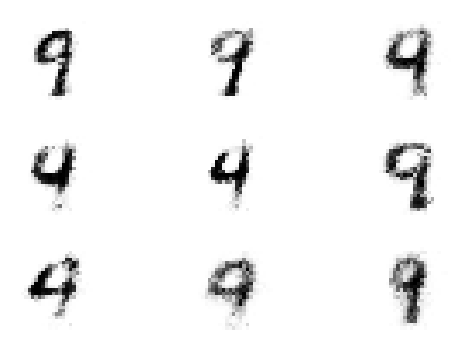

Epoch:145, D-Loss:0.188, D-Acc:96.667, G-Loss:3.352
Epoch:146, D-Loss:0.143, D-Acc:96.667, G-Loss:3.686
Epoch:147, D-Loss:0.185, D-Acc:98.333, G-Loss:3.701
Epoch:148, D-Loss:0.357, D-Acc:91.667, G-Loss:2.953
Epoch:149, D-Loss:0.223, D-Acc:93.333, G-Loss:2.692


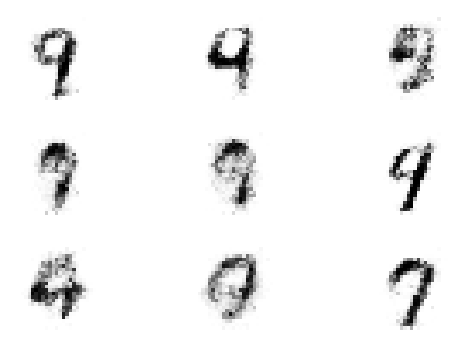

Epoch:150, D-Loss:0.293, D-Acc:93.333, G-Loss:3.466
Epoch:151, D-Loss:0.206, D-Acc:96.667, G-Loss:3.376
Epoch:152, D-Loss:0.088, D-Acc:98.333, G-Loss:3.670
Epoch:153, D-Loss:0.123, D-Acc:100.000, G-Loss:3.578
Epoch:154, D-Loss:0.189, D-Acc:96.667, G-Loss:3.419


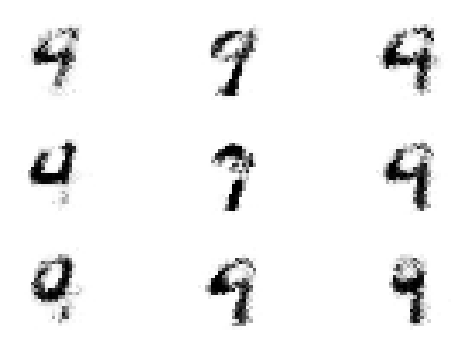

Epoch:155, D-Loss:0.262, D-Acc:95.000, G-Loss:3.602
Epoch:156, D-Loss:0.125, D-Acc:96.667, G-Loss:4.105
Epoch:157, D-Loss:0.413, D-Acc:88.333, G-Loss:3.439
Epoch:158, D-Loss:0.115, D-Acc:100.000, G-Loss:2.935
Epoch:159, D-Loss:0.137, D-Acc:98.333, G-Loss:3.469


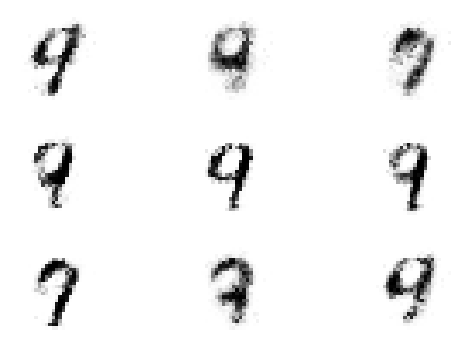

Epoch:160, D-Loss:0.259, D-Acc:95.000, G-Loss:3.413
Epoch:161, D-Loss:0.265, D-Acc:91.667, G-Loss:2.966
Epoch:162, D-Loss:0.243, D-Acc:96.667, G-Loss:3.218
Epoch:163, D-Loss:0.156, D-Acc:98.333, G-Loss:3.163
Epoch:164, D-Loss:0.173, D-Acc:96.667, G-Loss:3.294


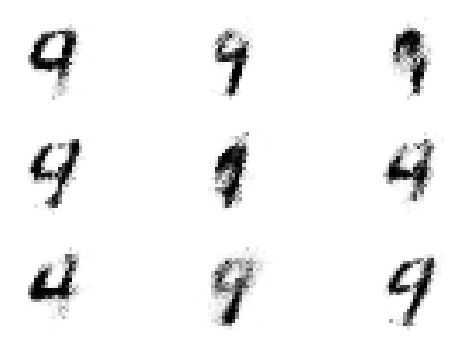

Epoch:165, D-Loss:0.256, D-Acc:95.000, G-Loss:3.186
Epoch:166, D-Loss:0.246, D-Acc:95.000, G-Loss:3.344
Epoch:167, D-Loss:0.309, D-Acc:93.333, G-Loss:2.788
Epoch:168, D-Loss:0.125, D-Acc:96.667, G-Loss:2.977
Epoch:169, D-Loss:0.328, D-Acc:95.000, G-Loss:2.982


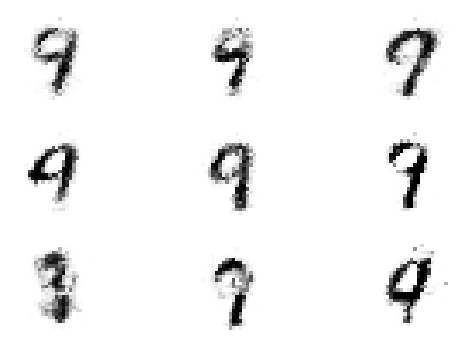

Epoch:170, D-Loss:0.292, D-Acc:95.000, G-Loss:3.239
Epoch:171, D-Loss:0.376, D-Acc:90.000, G-Loss:3.242
Epoch:172, D-Loss:0.276, D-Acc:95.000, G-Loss:2.793
Epoch:173, D-Loss:0.477, D-Acc:88.333, G-Loss:2.702
Epoch:174, D-Loss:0.273, D-Acc:95.000, G-Loss:3.796


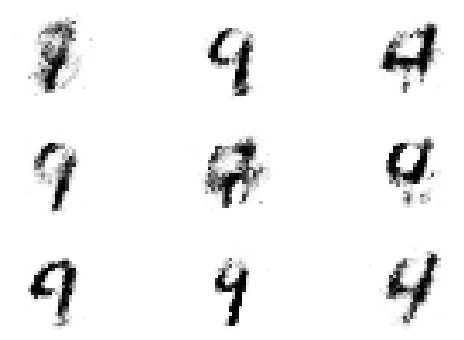

Epoch:175, D-Loss:0.356, D-Acc:93.333, G-Loss:2.667
Epoch:176, D-Loss:0.620, D-Acc:86.667, G-Loss:2.232
Epoch:177, D-Loss:0.452, D-Acc:88.333, G-Loss:3.740
Epoch:178, D-Loss:0.558, D-Acc:91.667, G-Loss:3.173
Epoch:179, D-Loss:0.323, D-Acc:96.667, G-Loss:2.235


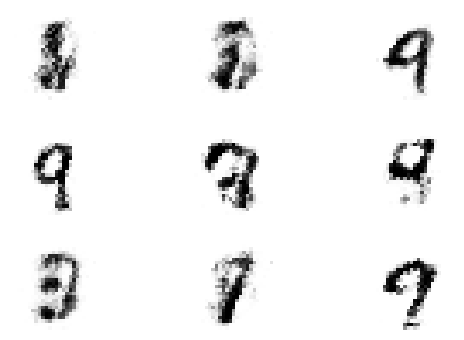

Epoch:180, D-Loss:0.301, D-Acc:95.000, G-Loss:2.933
Epoch:181, D-Loss:0.438, D-Acc:91.667, G-Loss:2.844
Epoch:182, D-Loss:0.441, D-Acc:86.667, G-Loss:2.826
Epoch:183, D-Loss:0.360, D-Acc:95.000, G-Loss:3.175
Epoch:184, D-Loss:0.265, D-Acc:96.667, G-Loss:3.454


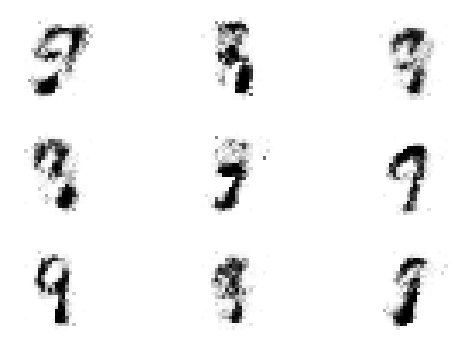

Epoch:185, D-Loss:0.497, D-Acc:85.000, G-Loss:2.822
Epoch:186, D-Loss:0.329, D-Acc:90.000, G-Loss:3.118
Epoch:187, D-Loss:0.408, D-Acc:91.667, G-Loss:3.023
Epoch:188, D-Loss:0.221, D-Acc:95.000, G-Loss:3.731
Epoch:189, D-Loss:0.255, D-Acc:95.000, G-Loss:2.808


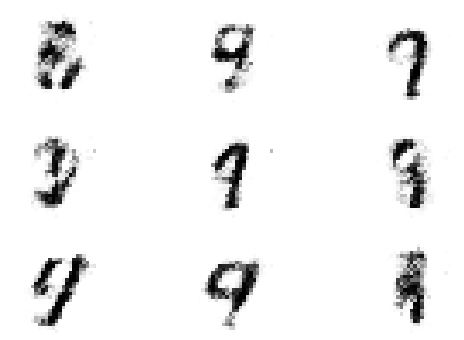

Epoch:190, D-Loss:0.551, D-Acc:88.333, G-Loss:2.794
Epoch:191, D-Loss:0.374, D-Acc:91.667, G-Loss:3.159
Epoch:192, D-Loss:0.332, D-Acc:95.000, G-Loss:3.164
Epoch:193, D-Loss:0.535, D-Acc:90.000, G-Loss:2.396
Epoch:194, D-Loss:0.622, D-Acc:88.333, G-Loss:3.367


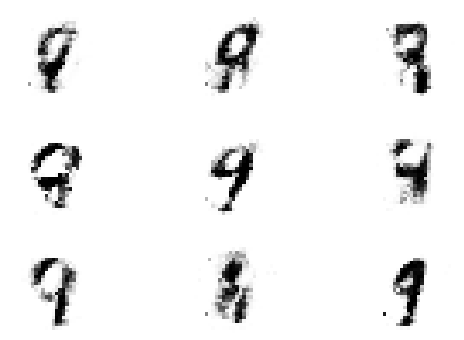

Epoch:195, D-Loss:0.356, D-Acc:95.000, G-Loss:2.948
Epoch:196, D-Loss:0.223, D-Acc:96.667, G-Loss:2.768
Epoch:197, D-Loss:0.278, D-Acc:96.667, G-Loss:2.394
Epoch:198, D-Loss:0.627, D-Acc:85.000, G-Loss:2.468
Epoch:199, D-Loss:0.487, D-Acc:90.000, G-Loss:2.783


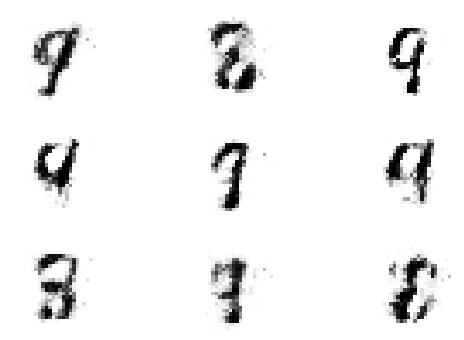

Epoch:200, D-Loss:0.372, D-Acc:91.667, G-Loss:2.741
Epoch:201, D-Loss:0.348, D-Acc:93.333, G-Loss:2.330
Epoch:202, D-Loss:0.586, D-Acc:91.667, G-Loss:2.685
Epoch:203, D-Loss:0.392, D-Acc:91.667, G-Loss:3.014
Epoch:204, D-Loss:0.410, D-Acc:90.000, G-Loss:3.316


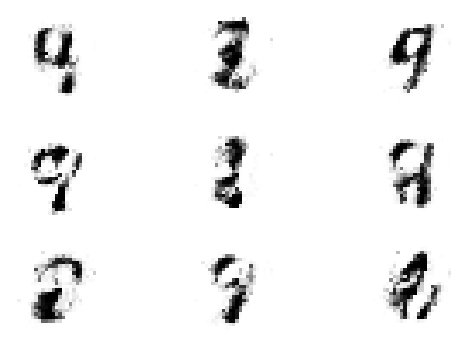

Epoch:205, D-Loss:0.467, D-Acc:91.667, G-Loss:2.754
Epoch:206, D-Loss:0.397, D-Acc:91.667, G-Loss:2.798
Epoch:207, D-Loss:0.607, D-Acc:85.000, G-Loss:2.563
Epoch:208, D-Loss:0.571, D-Acc:83.333, G-Loss:2.467
Epoch:209, D-Loss:0.282, D-Acc:95.000, G-Loss:2.297


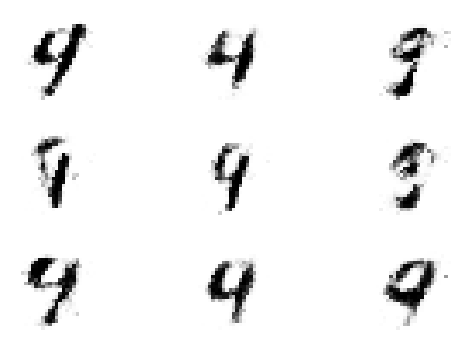

Epoch:210, D-Loss:0.224, D-Acc:96.667, G-Loss:2.377
Epoch:211, D-Loss:0.324, D-Acc:93.333, G-Loss:2.444
Epoch:212, D-Loss:0.656, D-Acc:88.333, G-Loss:2.134
Epoch:213, D-Loss:0.329, D-Acc:91.667, G-Loss:2.581
Epoch:214, D-Loss:0.339, D-Acc:91.667, G-Loss:2.667


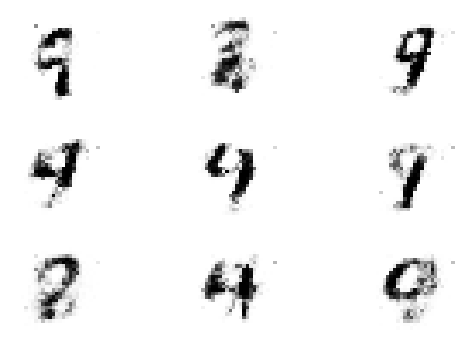

Epoch:215, D-Loss:0.277, D-Acc:95.000, G-Loss:2.595
Epoch:216, D-Loss:0.593, D-Acc:88.333, G-Loss:3.216
Epoch:217, D-Loss:0.487, D-Acc:93.333, G-Loss:2.969
Epoch:218, D-Loss:0.650, D-Acc:80.000, G-Loss:2.198
Epoch:219, D-Loss:0.291, D-Acc:93.333, G-Loss:2.932


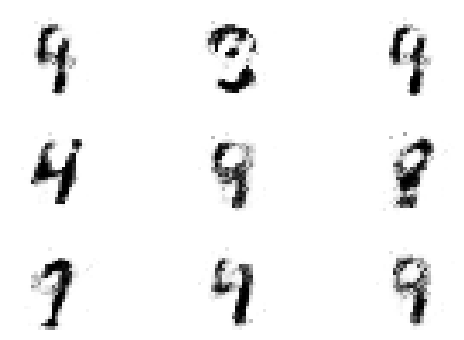

Epoch:220, D-Loss:0.433, D-Acc:91.667, G-Loss:3.236
Epoch:221, D-Loss:0.568, D-Acc:90.000, G-Loss:2.847
Epoch:222, D-Loss:0.435, D-Acc:90.000, G-Loss:3.006
Epoch:223, D-Loss:0.378, D-Acc:91.667, G-Loss:2.205
Epoch:224, D-Loss:0.369, D-Acc:93.333, G-Loss:2.624


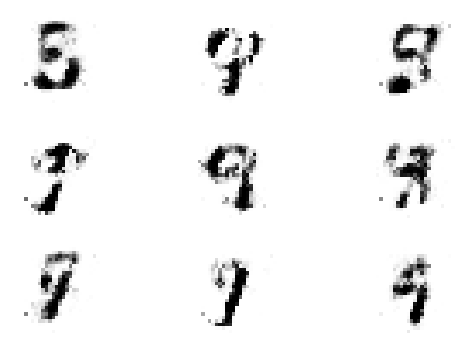

Epoch:225, D-Loss:0.690, D-Acc:90.000, G-Loss:2.842
Epoch:226, D-Loss:0.298, D-Acc:95.000, G-Loss:2.516
Epoch:227, D-Loss:0.356, D-Acc:93.333, G-Loss:2.642
Epoch:228, D-Loss:0.594, D-Acc:81.667, G-Loss:2.228
Epoch:229, D-Loss:0.500, D-Acc:95.000, G-Loss:2.268


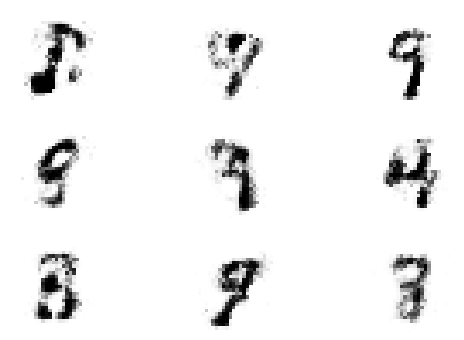

Epoch:230, D-Loss:0.404, D-Acc:91.667, G-Loss:2.273
Epoch:231, D-Loss:0.605, D-Acc:86.667, G-Loss:2.227
Epoch:232, D-Loss:0.584, D-Acc:86.667, G-Loss:2.373
Epoch:233, D-Loss:0.504, D-Acc:90.000, G-Loss:2.148
Epoch:234, D-Loss:0.583, D-Acc:88.333, G-Loss:1.982


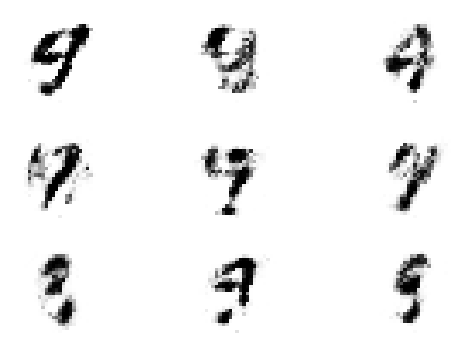

Epoch:235, D-Loss:0.513, D-Acc:90.000, G-Loss:2.478
Epoch:236, D-Loss:0.241, D-Acc:98.333, G-Loss:2.943
Epoch:237, D-Loss:0.527, D-Acc:91.667, G-Loss:2.329
Epoch:238, D-Loss:0.606, D-Acc:86.667, G-Loss:2.287
Epoch:239, D-Loss:0.611, D-Acc:86.667, G-Loss:2.226


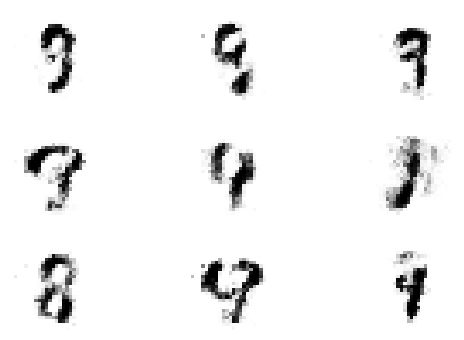

Epoch:240, D-Loss:0.458, D-Acc:90.000, G-Loss:2.725
Epoch:241, D-Loss:0.429, D-Acc:91.667, G-Loss:2.430
Epoch:242, D-Loss:0.470, D-Acc:88.333, G-Loss:2.726
Epoch:243, D-Loss:0.614, D-Acc:83.333, G-Loss:2.412
Epoch:244, D-Loss:0.421, D-Acc:88.333, G-Loss:2.692


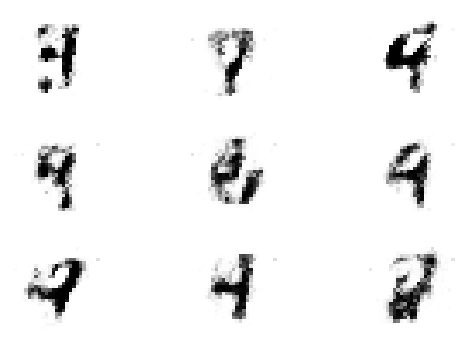

Epoch:245, D-Loss:0.656, D-Acc:85.000, G-Loss:2.407
Epoch:246, D-Loss:0.723, D-Acc:83.333, G-Loss:2.382
Epoch:247, D-Loss:0.495, D-Acc:85.000, G-Loss:2.304
Epoch:248, D-Loss:0.529, D-Acc:85.000, G-Loss:2.251
Epoch:249, D-Loss:0.459, D-Acc:93.333, G-Loss:2.717


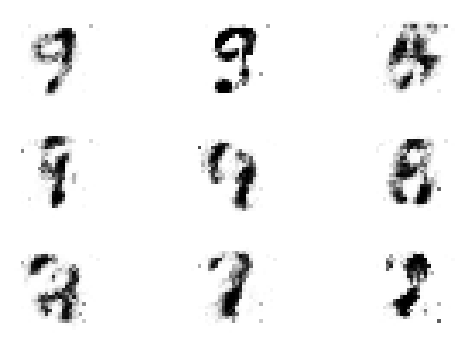

Epoch:250, D-Loss:0.536, D-Acc:88.333, G-Loss:2.839
Epoch:251, D-Loss:0.459, D-Acc:88.333, G-Loss:2.583
Epoch:252, D-Loss:0.474, D-Acc:88.333, G-Loss:2.266
Epoch:253, D-Loss:0.450, D-Acc:90.000, G-Loss:2.662
Epoch:254, D-Loss:0.383, D-Acc:93.333, G-Loss:2.391


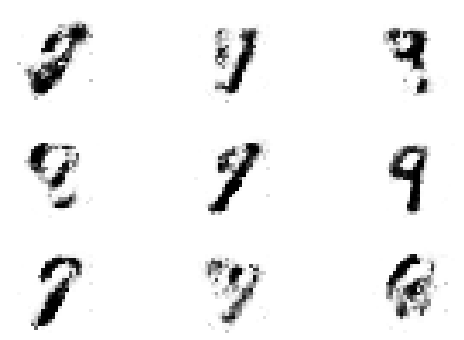

Epoch:255, D-Loss:0.526, D-Acc:90.000, G-Loss:2.126
Epoch:256, D-Loss:0.316, D-Acc:95.000, G-Loss:3.011
Epoch:257, D-Loss:0.462, D-Acc:90.000, G-Loss:2.408
Epoch:258, D-Loss:0.669, D-Acc:83.333, G-Loss:2.178
Epoch:259, D-Loss:0.615, D-Acc:90.000, G-Loss:2.419


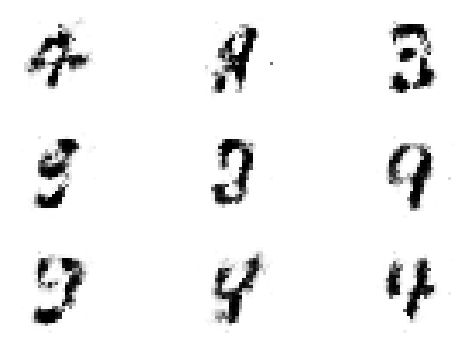

Epoch:260, D-Loss:0.414, D-Acc:91.667, G-Loss:2.298
Epoch:261, D-Loss:0.395, D-Acc:90.000, G-Loss:2.553
Epoch:262, D-Loss:0.508, D-Acc:91.667, G-Loss:2.228
Epoch:263, D-Loss:0.565, D-Acc:83.333, G-Loss:2.457
Epoch:264, D-Loss:0.295, D-Acc:95.000, G-Loss:1.965


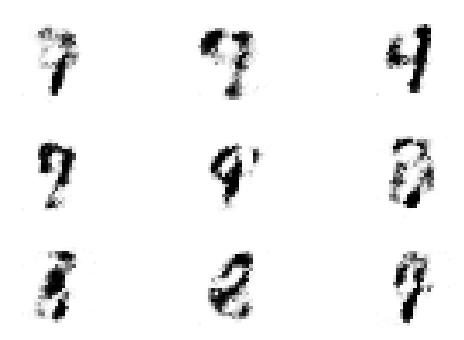

Epoch:265, D-Loss:0.474, D-Acc:90.000, G-Loss:2.162
Epoch:266, D-Loss:0.736, D-Acc:83.333, G-Loss:2.186
Epoch:267, D-Loss:0.636, D-Acc:90.000, G-Loss:2.219
Epoch:268, D-Loss:0.343, D-Acc:93.333, G-Loss:2.668
Epoch:269, D-Loss:0.399, D-Acc:91.667, G-Loss:2.277


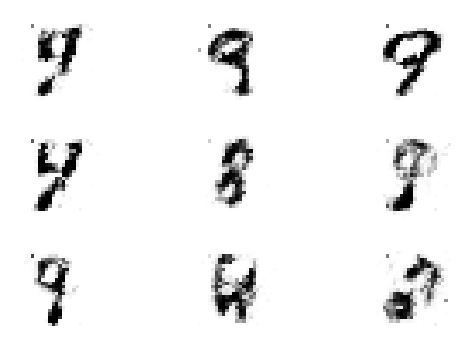

Epoch:270, D-Loss:0.387, D-Acc:93.333, G-Loss:2.455
Epoch:271, D-Loss:0.525, D-Acc:90.000, G-Loss:2.334
Epoch:272, D-Loss:0.339, D-Acc:91.667, G-Loss:2.235
Epoch:273, D-Loss:0.613, D-Acc:85.000, G-Loss:2.603
Epoch:274, D-Loss:0.457, D-Acc:93.333, G-Loss:2.194


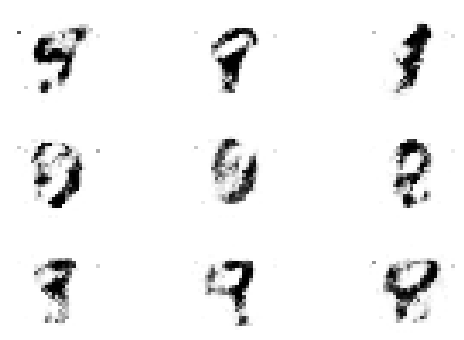

Epoch:275, D-Loss:0.524, D-Acc:86.667, G-Loss:2.559
Epoch:276, D-Loss:0.719, D-Acc:85.000, G-Loss:2.435
Epoch:277, D-Loss:0.462, D-Acc:91.667, G-Loss:2.396
Epoch:278, D-Loss:0.456, D-Acc:90.000, G-Loss:2.682
Epoch:279, D-Loss:0.613, D-Acc:86.667, G-Loss:2.700


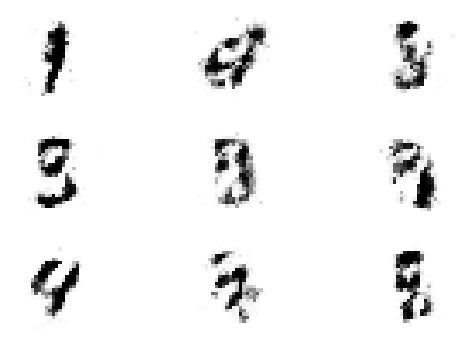

Epoch:280, D-Loss:0.513, D-Acc:91.667, G-Loss:2.771
Epoch:281, D-Loss:0.497, D-Acc:88.333, G-Loss:2.169
Epoch:282, D-Loss:0.353, D-Acc:95.000, G-Loss:2.516
Epoch:283, D-Loss:0.395, D-Acc:95.000, G-Loss:2.487
Epoch:284, D-Loss:0.455, D-Acc:91.667, G-Loss:2.653


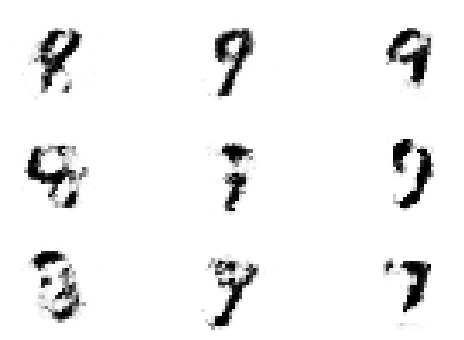

Epoch:285, D-Loss:0.529, D-Acc:88.333, G-Loss:2.484
Epoch:286, D-Loss:0.691, D-Acc:83.333, G-Loss:2.486
Epoch:287, D-Loss:0.552, D-Acc:85.000, G-Loss:2.509
Epoch:288, D-Loss:0.387, D-Acc:95.000, G-Loss:2.432
Epoch:289, D-Loss:0.578, D-Acc:85.000, G-Loss:2.667


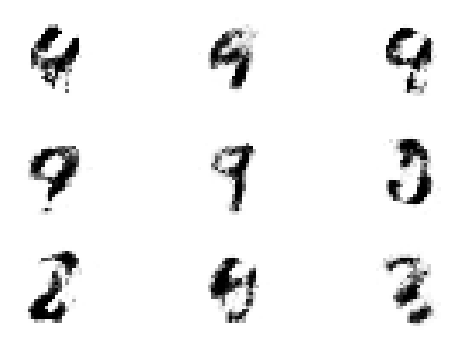

Epoch:290, D-Loss:0.632, D-Acc:86.667, G-Loss:2.308
Epoch:291, D-Loss:0.584, D-Acc:86.667, G-Loss:2.076
Epoch:292, D-Loss:0.431, D-Acc:93.333, G-Loss:2.531
Epoch:293, D-Loss:0.691, D-Acc:81.667, G-Loss:2.450
Epoch:294, D-Loss:0.454, D-Acc:95.000, G-Loss:2.851


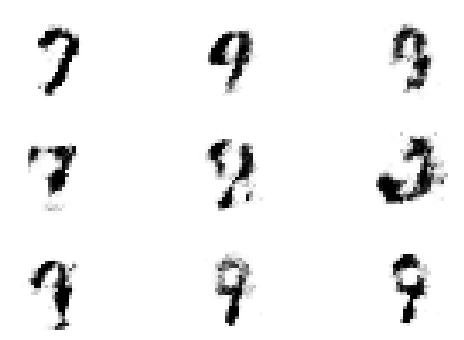

Epoch:295, D-Loss:0.702, D-Acc:81.667, G-Loss:2.162
Epoch:296, D-Loss:0.598, D-Acc:88.333, G-Loss:2.379
Epoch:297, D-Loss:0.338, D-Acc:93.333, G-Loss:2.582
Epoch:298, D-Loss:0.436, D-Acc:91.667, G-Loss:2.303
Epoch:299, D-Loss:0.677, D-Acc:81.667, G-Loss:2.472


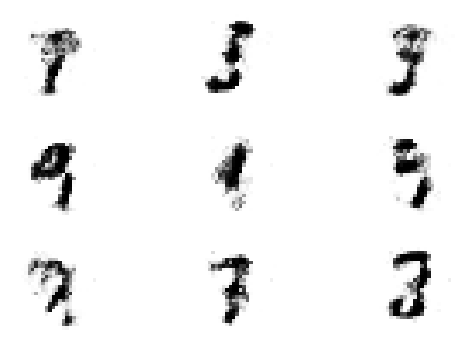

Epoch:300, D-Loss:0.486, D-Acc:91.667, G-Loss:2.438
Epoch:301, D-Loss:0.286, D-Acc:96.667, G-Loss:2.296
Epoch:302, D-Loss:0.620, D-Acc:85.000, G-Loss:2.231
Epoch:303, D-Loss:0.421, D-Acc:90.000, G-Loss:2.493
Epoch:304, D-Loss:0.652, D-Acc:80.000, G-Loss:2.860


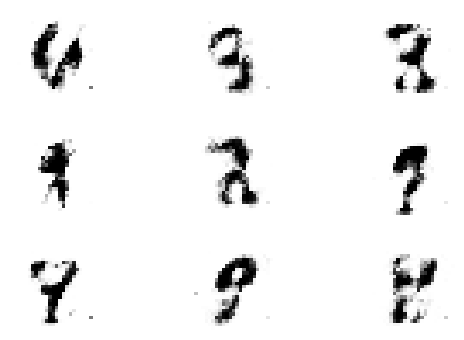

Epoch:305, D-Loss:0.639, D-Acc:85.000, G-Loss:2.518
Epoch:306, D-Loss:0.540, D-Acc:85.000, G-Loss:2.290
Epoch:307, D-Loss:0.381, D-Acc:93.333, G-Loss:3.024
Epoch:308, D-Loss:0.438, D-Acc:93.333, G-Loss:2.906
Epoch:309, D-Loss:0.568, D-Acc:86.667, G-Loss:2.211


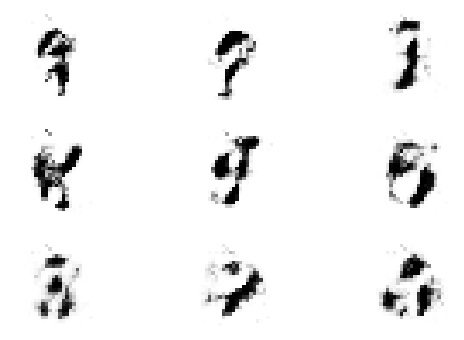

Epoch:310, D-Loss:0.453, D-Acc:88.333, G-Loss:2.650
Epoch:311, D-Loss:0.592, D-Acc:91.667, G-Loss:2.427
Epoch:312, D-Loss:0.408, D-Acc:90.000, G-Loss:2.692
Epoch:313, D-Loss:0.515, D-Acc:88.333, G-Loss:2.578
Epoch:314, D-Loss:0.541, D-Acc:90.000, G-Loss:2.677


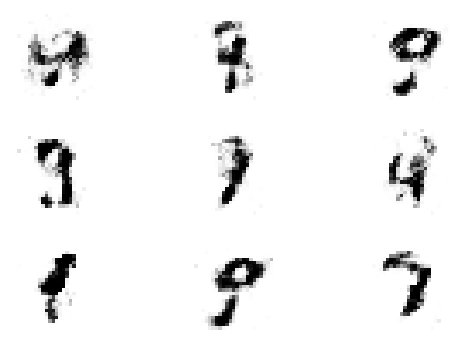

Epoch:315, D-Loss:0.293, D-Acc:93.333, G-Loss:2.754
Epoch:316, D-Loss:0.600, D-Acc:86.667, G-Loss:2.235
Epoch:317, D-Loss:0.465, D-Acc:90.000, G-Loss:2.466
Epoch:318, D-Loss:0.353, D-Acc:91.667, G-Loss:2.805
Epoch:319, D-Loss:0.625, D-Acc:86.667, G-Loss:2.574


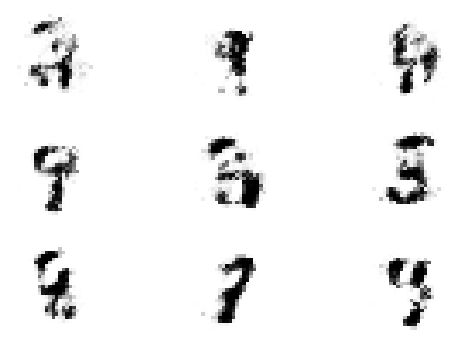

Epoch:320, D-Loss:0.745, D-Acc:81.667, G-Loss:2.724
Epoch:321, D-Loss:0.665, D-Acc:86.667, G-Loss:2.192
Epoch:322, D-Loss:0.458, D-Acc:90.000, G-Loss:2.445
Epoch:323, D-Loss:0.593, D-Acc:85.000, G-Loss:2.684
Epoch:324, D-Loss:0.527, D-Acc:90.000, G-Loss:2.298


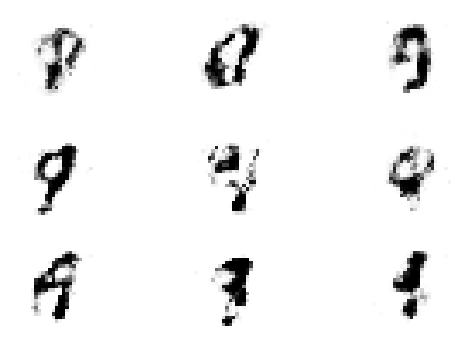

Epoch:325, D-Loss:0.491, D-Acc:90.000, G-Loss:2.300
Epoch:326, D-Loss:0.530, D-Acc:83.333, G-Loss:1.855
Epoch:327, D-Loss:0.960, D-Acc:75.000, G-Loss:2.083
Epoch:328, D-Loss:0.570, D-Acc:88.333, G-Loss:1.911
Epoch:329, D-Loss:0.627, D-Acc:85.000, G-Loss:2.040


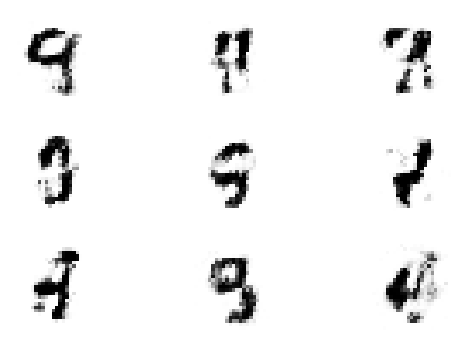

Epoch:330, D-Loss:0.796, D-Acc:83.333, G-Loss:2.244
Epoch:331, D-Loss:0.445, D-Acc:93.333, G-Loss:2.115
Epoch:332, D-Loss:0.479, D-Acc:90.000, G-Loss:2.245
Epoch:333, D-Loss:0.697, D-Acc:81.667, G-Loss:2.517
Epoch:334, D-Loss:0.388, D-Acc:91.667, G-Loss:2.320


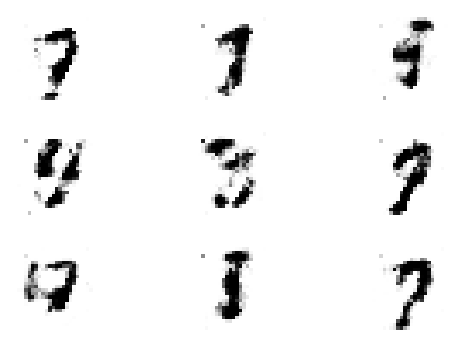

Epoch:335, D-Loss:0.745, D-Acc:85.000, G-Loss:2.484
Epoch:336, D-Loss:0.494, D-Acc:91.667, G-Loss:1.987
Epoch:337, D-Loss:0.963, D-Acc:78.333, G-Loss:1.823
Epoch:338, D-Loss:0.392, D-Acc:91.667, G-Loss:2.193
Epoch:339, D-Loss:0.587, D-Acc:88.333, G-Loss:2.157


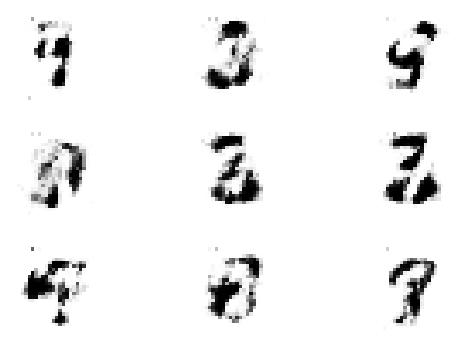

Epoch:340, D-Loss:0.373, D-Acc:95.000, G-Loss:2.627
Epoch:341, D-Loss:0.629, D-Acc:85.000, G-Loss:2.164
Epoch:342, D-Loss:0.351, D-Acc:95.000, G-Loss:2.491
Epoch:343, D-Loss:0.457, D-Acc:90.000, G-Loss:2.255
Epoch:344, D-Loss:0.499, D-Acc:90.000, G-Loss:2.739


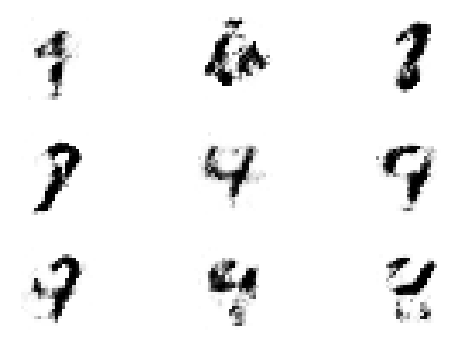

Epoch:345, D-Loss:0.643, D-Acc:88.333, G-Loss:2.662
Epoch:346, D-Loss:0.455, D-Acc:90.000, G-Loss:2.554
Epoch:347, D-Loss:0.735, D-Acc:83.333, G-Loss:1.897
Epoch:348, D-Loss:0.545, D-Acc:91.667, G-Loss:2.285
Epoch:349, D-Loss:0.415, D-Acc:91.667, G-Loss:2.217


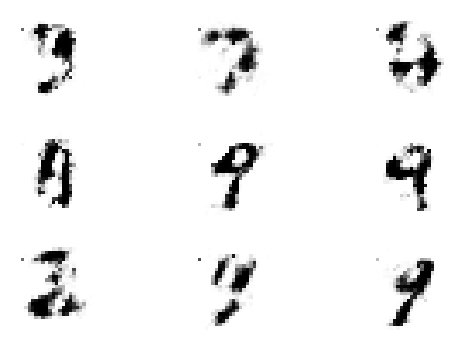

Epoch:350, D-Loss:0.593, D-Acc:86.667, G-Loss:2.247
Epoch:351, D-Loss:0.355, D-Acc:93.333, G-Loss:2.447
Epoch:352, D-Loss:0.573, D-Acc:86.667, G-Loss:2.131
Epoch:353, D-Loss:0.752, D-Acc:83.333, G-Loss:2.475
Epoch:354, D-Loss:0.600, D-Acc:83.333, G-Loss:2.257


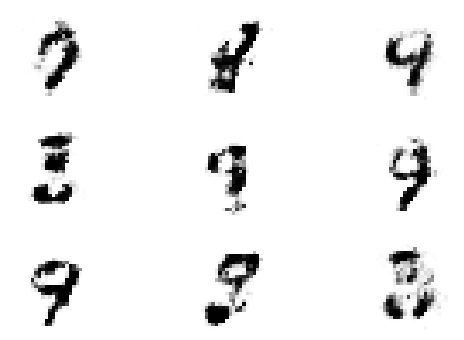

Epoch:355, D-Loss:0.987, D-Acc:80.000, G-Loss:1.769
Epoch:356, D-Loss:0.380, D-Acc:93.333, G-Loss:2.918
Epoch:357, D-Loss:0.736, D-Acc:88.333, G-Loss:2.648
Epoch:358, D-Loss:0.652, D-Acc:88.333, G-Loss:2.384
Epoch:359, D-Loss:0.471, D-Acc:88.333, G-Loss:2.160


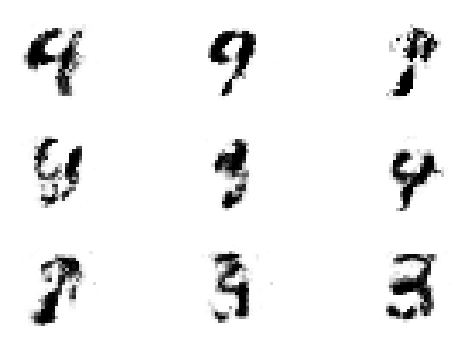

Epoch:360, D-Loss:0.407, D-Acc:93.333, G-Loss:2.634
Epoch:361, D-Loss:0.462, D-Acc:91.667, G-Loss:2.542
Epoch:362, D-Loss:0.297, D-Acc:98.333, G-Loss:2.215
Epoch:363, D-Loss:0.417, D-Acc:95.000, G-Loss:2.531
Epoch:364, D-Loss:0.343, D-Acc:95.000, G-Loss:2.432


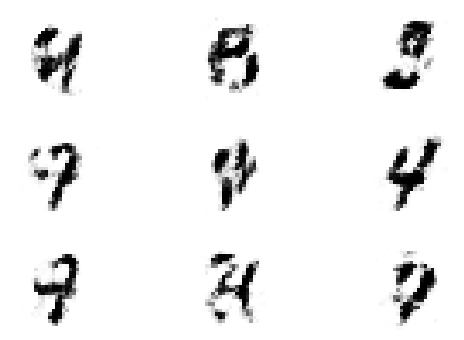

Epoch:365, D-Loss:0.386, D-Acc:95.000, G-Loss:2.646
Epoch:366, D-Loss:0.543, D-Acc:90.000, G-Loss:2.314
Epoch:367, D-Loss:0.532, D-Acc:90.000, G-Loss:2.645
Epoch:368, D-Loss:0.567, D-Acc:95.000, G-Loss:1.891
Epoch:369, D-Loss:0.412, D-Acc:95.000, G-Loss:2.141


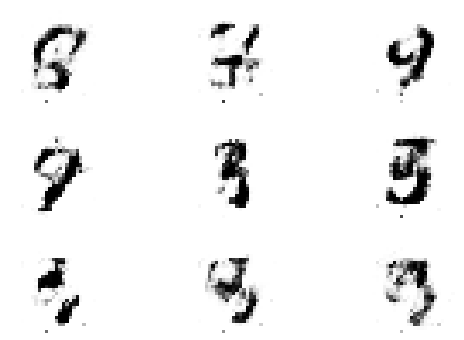

Epoch:370, D-Loss:0.276, D-Acc:98.333, G-Loss:2.889
Epoch:371, D-Loss:0.372, D-Acc:96.667, G-Loss:2.393
Epoch:372, D-Loss:0.353, D-Acc:93.333, G-Loss:1.814
Epoch:373, D-Loss:0.955, D-Acc:76.667, G-Loss:2.859
Epoch:374, D-Loss:0.353, D-Acc:93.333, G-Loss:2.573


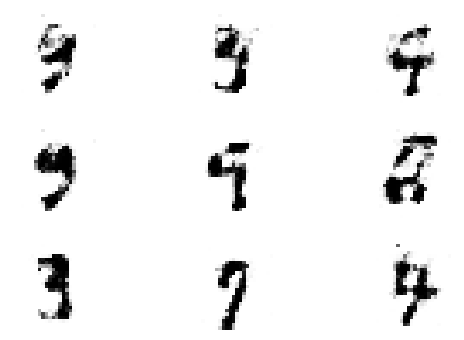

Epoch:375, D-Loss:0.268, D-Acc:98.333, G-Loss:2.270
Epoch:376, D-Loss:0.530, D-Acc:86.667, G-Loss:1.987
Epoch:377, D-Loss:0.212, D-Acc:98.333, G-Loss:2.177
Epoch:378, D-Loss:0.602, D-Acc:83.333, G-Loss:2.312
Epoch:379, D-Loss:0.428, D-Acc:91.667, G-Loss:2.596


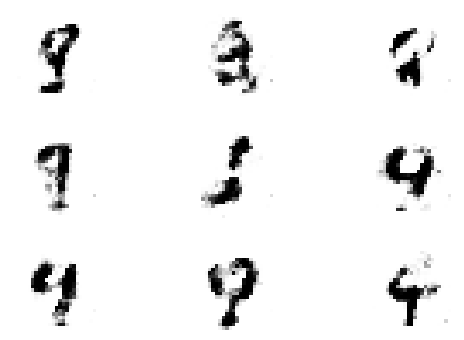

Epoch:380, D-Loss:0.587, D-Acc:83.333, G-Loss:2.171
Epoch:381, D-Loss:0.318, D-Acc:95.000, G-Loss:2.653
Epoch:382, D-Loss:0.502, D-Acc:90.000, G-Loss:2.466
Epoch:383, D-Loss:0.576, D-Acc:83.333, G-Loss:2.439
Epoch:384, D-Loss:0.518, D-Acc:86.667, G-Loss:2.192


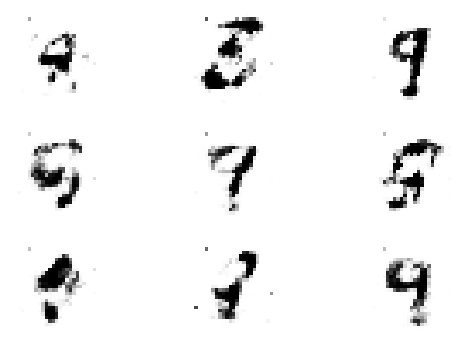

Epoch:385, D-Loss:0.542, D-Acc:91.667, G-Loss:2.053
Epoch:386, D-Loss:0.356, D-Acc:95.000, G-Loss:1.821
Epoch:387, D-Loss:0.501, D-Acc:91.667, G-Loss:2.463
Epoch:388, D-Loss:0.350, D-Acc:96.667, G-Loss:2.538
Epoch:389, D-Loss:0.561, D-Acc:86.667, G-Loss:3.148


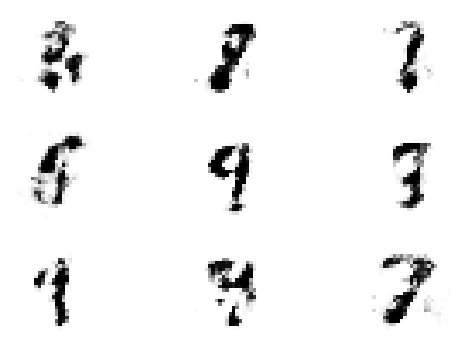

Epoch:390, D-Loss:0.299, D-Acc:93.333, G-Loss:2.585
Epoch:391, D-Loss:0.670, D-Acc:81.667, G-Loss:2.170
Epoch:392, D-Loss:0.494, D-Acc:95.000, G-Loss:2.734
Epoch:393, D-Loss:0.549, D-Acc:86.667, G-Loss:2.513
Epoch:394, D-Loss:0.669, D-Acc:85.000, G-Loss:2.494


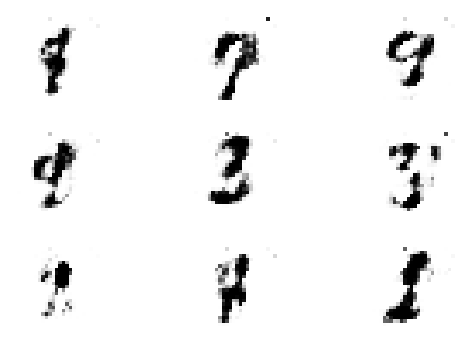

Epoch:395, D-Loss:0.427, D-Acc:93.333, G-Loss:2.791
Epoch:396, D-Loss:0.452, D-Acc:90.000, G-Loss:2.627
Epoch:397, D-Loss:0.495, D-Acc:88.333, G-Loss:2.370
Epoch:398, D-Loss:0.500, D-Acc:91.667, G-Loss:2.715
Epoch:399, D-Loss:0.424, D-Acc:93.333, G-Loss:2.104


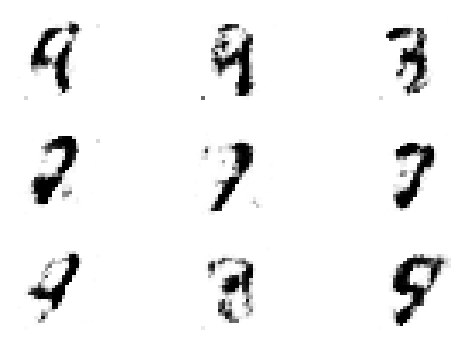

Epoch:400, D-Loss:0.577, D-Acc:88.333, G-Loss:2.659
Epoch:401, D-Loss:0.510, D-Acc:91.667, G-Loss:2.092
Epoch:402, D-Loss:0.436, D-Acc:88.333, G-Loss:2.979
Epoch:403, D-Loss:0.685, D-Acc:85.000, G-Loss:3.000
Epoch:404, D-Loss:0.358, D-Acc:93.333, G-Loss:2.350


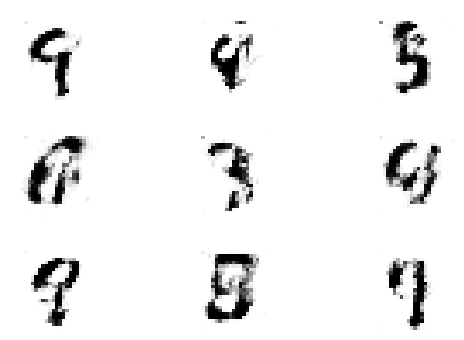

Epoch:405, D-Loss:0.614, D-Acc:86.667, G-Loss:3.300
Epoch:406, D-Loss:0.742, D-Acc:83.333, G-Loss:2.752
Epoch:407, D-Loss:0.414, D-Acc:93.333, G-Loss:2.696
Epoch:408, D-Loss:0.649, D-Acc:83.333, G-Loss:3.003
Epoch:409, D-Loss:0.586, D-Acc:88.333, G-Loss:2.545


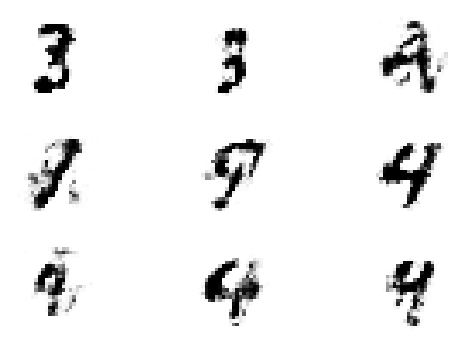

Epoch:410, D-Loss:0.384, D-Acc:90.000, G-Loss:2.573
Epoch:411, D-Loss:0.516, D-Acc:90.000, G-Loss:2.356
Epoch:412, D-Loss:0.572, D-Acc:90.000, G-Loss:2.610
Epoch:413, D-Loss:0.374, D-Acc:93.333, G-Loss:2.864
Epoch:414, D-Loss:0.595, D-Acc:86.667, G-Loss:2.630


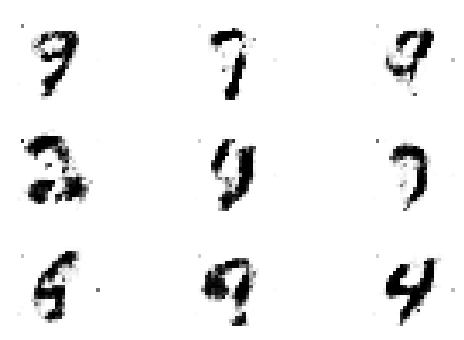

Epoch:415, D-Loss:0.674, D-Acc:81.667, G-Loss:2.687
Epoch:416, D-Loss:0.914, D-Acc:81.667, G-Loss:2.492
Epoch:417, D-Loss:0.686, D-Acc:83.333, G-Loss:2.375
Epoch:418, D-Loss:0.410, D-Acc:93.333, G-Loss:2.609
Epoch:419, D-Loss:0.475, D-Acc:88.333, G-Loss:2.526


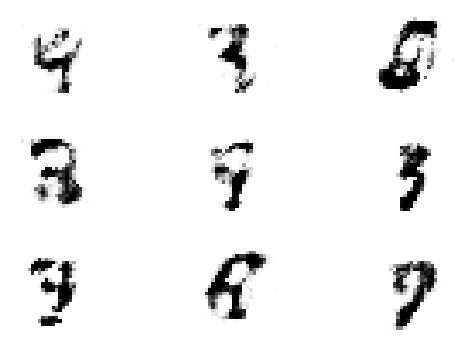

Epoch:420, D-Loss:0.623, D-Acc:86.667, G-Loss:2.939
Epoch:421, D-Loss:0.416, D-Acc:93.333, G-Loss:2.448
Epoch:422, D-Loss:0.473, D-Acc:91.667, G-Loss:2.878
Epoch:423, D-Loss:0.405, D-Acc:91.667, G-Loss:2.406
Epoch:424, D-Loss:0.736, D-Acc:85.000, G-Loss:2.630


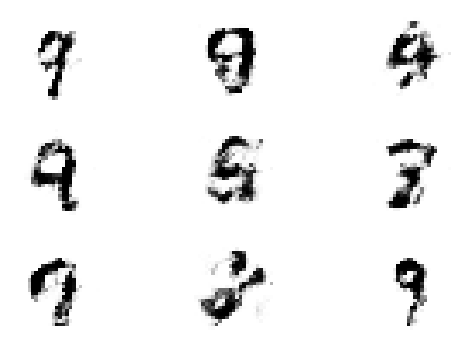

Epoch:425, D-Loss:0.761, D-Acc:85.000, G-Loss:2.433
Epoch:426, D-Loss:0.500, D-Acc:85.000, G-Loss:2.120
Epoch:427, D-Loss:0.352, D-Acc:95.000, G-Loss:2.732
Epoch:428, D-Loss:0.316, D-Acc:96.667, G-Loss:2.510
Epoch:429, D-Loss:0.291, D-Acc:96.667, G-Loss:2.901


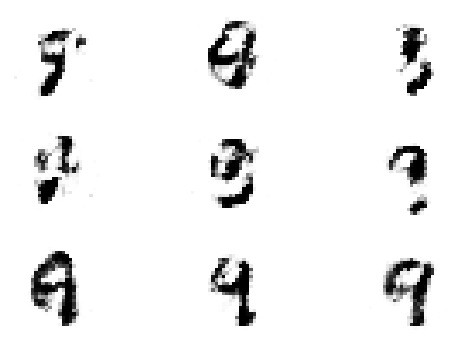

Epoch:430, D-Loss:0.569, D-Acc:85.000, G-Loss:2.662
Epoch:431, D-Loss:0.370, D-Acc:91.667, G-Loss:2.120
Epoch:432, D-Loss:0.594, D-Acc:81.667, G-Loss:2.283
Epoch:433, D-Loss:0.429, D-Acc:90.000, G-Loss:2.638
Epoch:434, D-Loss:0.610, D-Acc:88.333, G-Loss:2.094


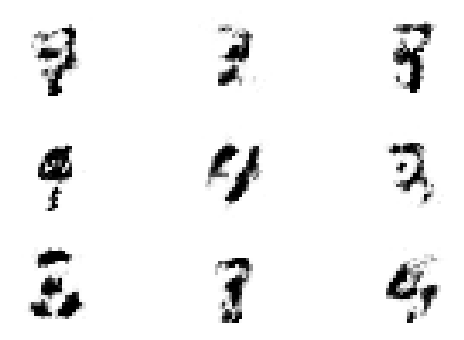

Epoch:435, D-Loss:0.608, D-Acc:83.333, G-Loss:2.827
Epoch:436, D-Loss:0.463, D-Acc:93.333, G-Loss:2.567
Epoch:437, D-Loss:0.478, D-Acc:91.667, G-Loss:2.182
Epoch:438, D-Loss:0.448, D-Acc:90.000, G-Loss:2.756
Epoch:439, D-Loss:0.528, D-Acc:85.000, G-Loss:2.167


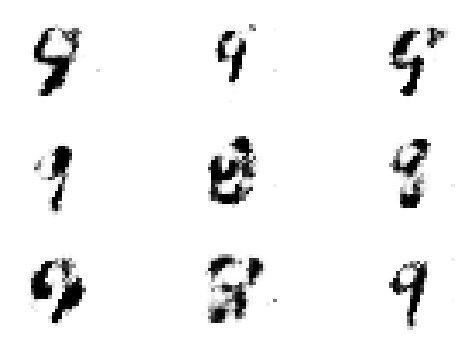

Epoch:440, D-Loss:0.441, D-Acc:88.333, G-Loss:2.296
Epoch:441, D-Loss:0.553, D-Acc:86.667, G-Loss:2.314
Epoch:442, D-Loss:0.415, D-Acc:91.667, G-Loss:2.220
Epoch:443, D-Loss:0.642, D-Acc:86.667, G-Loss:2.229
Epoch:444, D-Loss:0.585, D-Acc:85.000, G-Loss:2.584


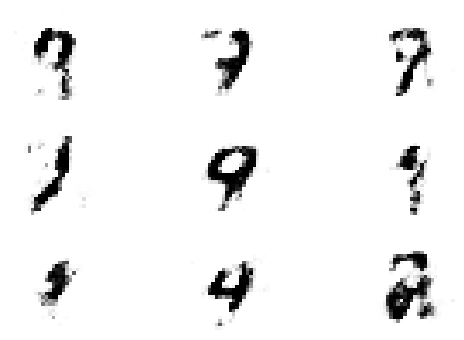

Epoch:445, D-Loss:0.383, D-Acc:88.333, G-Loss:2.289
Epoch:446, D-Loss:0.489, D-Acc:93.333, G-Loss:2.362
Epoch:447, D-Loss:0.468, D-Acc:90.000, G-Loss:2.599
Epoch:448, D-Loss:0.497, D-Acc:90.000, G-Loss:2.943
Epoch:449, D-Loss:0.354, D-Acc:95.000, G-Loss:2.650


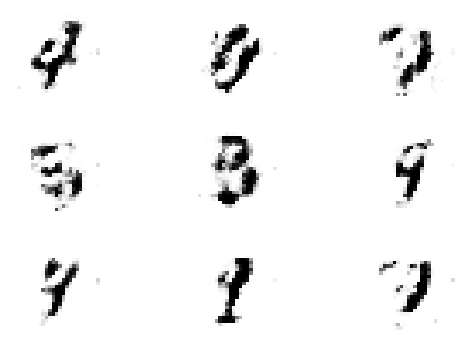

Epoch:450, D-Loss:0.660, D-Acc:83.333, G-Loss:2.540
Epoch:451, D-Loss:0.484, D-Acc:88.333, G-Loss:2.913
Epoch:452, D-Loss:0.734, D-Acc:80.000, G-Loss:2.349
Epoch:453, D-Loss:0.254, D-Acc:95.000, G-Loss:2.519
Epoch:454, D-Loss:0.356, D-Acc:95.000, G-Loss:2.364


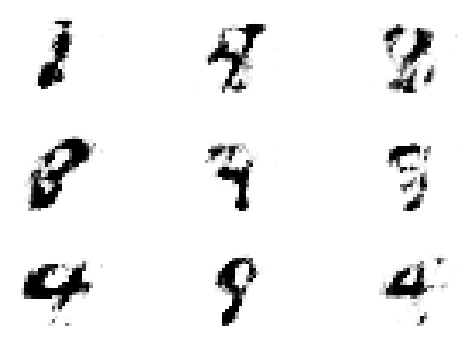

Epoch:455, D-Loss:0.656, D-Acc:88.333, G-Loss:2.642
Epoch:456, D-Loss:0.363, D-Acc:91.667, G-Loss:2.862
Epoch:457, D-Loss:0.629, D-Acc:85.000, G-Loss:2.637
Epoch:458, D-Loss:0.388, D-Acc:93.333, G-Loss:2.464
Epoch:459, D-Loss:0.660, D-Acc:85.000, G-Loss:2.491


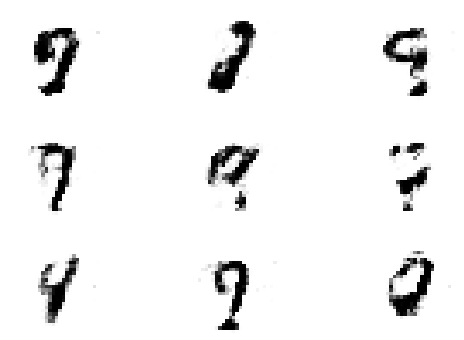

Epoch:460, D-Loss:0.488, D-Acc:86.667, G-Loss:2.885
Epoch:461, D-Loss:0.506, D-Acc:85.000, G-Loss:2.351
Epoch:462, D-Loss:0.600, D-Acc:83.333, G-Loss:2.649
Epoch:463, D-Loss:0.344, D-Acc:91.667, G-Loss:2.857
Epoch:464, D-Loss:0.422, D-Acc:93.333, G-Loss:2.006


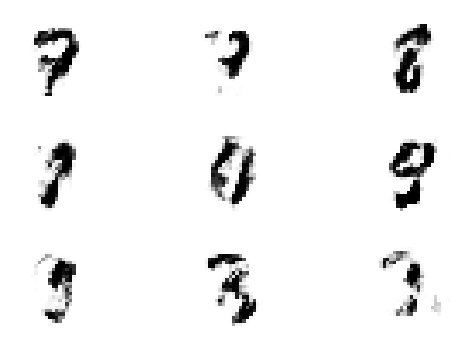

Epoch:465, D-Loss:0.709, D-Acc:83.333, G-Loss:2.497
Epoch:466, D-Loss:0.462, D-Acc:88.333, G-Loss:2.269
Epoch:467, D-Loss:0.420, D-Acc:88.333, G-Loss:2.269
Epoch:468, D-Loss:0.392, D-Acc:91.667, G-Loss:2.542
Epoch:469, D-Loss:0.555, D-Acc:91.667, G-Loss:2.777


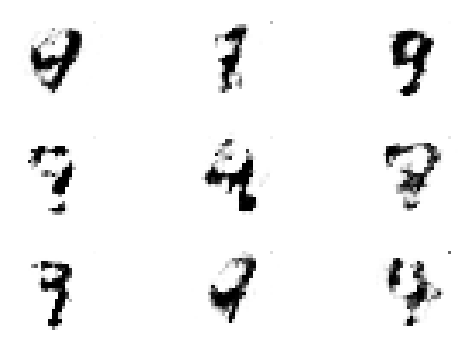

Epoch:470, D-Loss:0.240, D-Acc:95.000, G-Loss:2.979
Epoch:471, D-Loss:0.484, D-Acc:91.667, G-Loss:2.699
Epoch:472, D-Loss:0.605, D-Acc:85.000, G-Loss:2.330
Epoch:473, D-Loss:0.410, D-Acc:93.333, G-Loss:3.091
Epoch:474, D-Loss:0.371, D-Acc:93.333, G-Loss:2.757


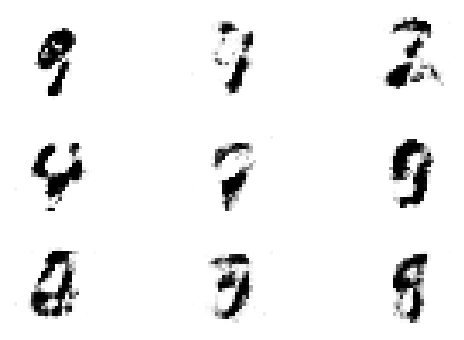

Epoch:475, D-Loss:0.428, D-Acc:93.333, G-Loss:2.694
Epoch:476, D-Loss:0.497, D-Acc:91.667, G-Loss:2.373
Epoch:477, D-Loss:0.702, D-Acc:86.667, G-Loss:2.869
Epoch:478, D-Loss:0.474, D-Acc:93.333, G-Loss:2.990
Epoch:479, D-Loss:0.488, D-Acc:86.667, G-Loss:2.353


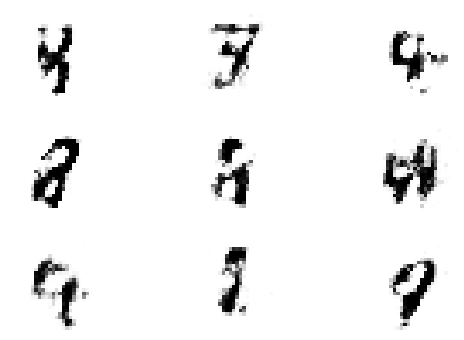

Epoch:480, D-Loss:0.324, D-Acc:93.333, G-Loss:2.519
Epoch:481, D-Loss:0.442, D-Acc:91.667, G-Loss:2.543
Epoch:482, D-Loss:0.418, D-Acc:88.333, G-Loss:2.730
Epoch:483, D-Loss:0.361, D-Acc:93.333, G-Loss:2.924
Epoch:484, D-Loss:0.360, D-Acc:91.667, G-Loss:2.593


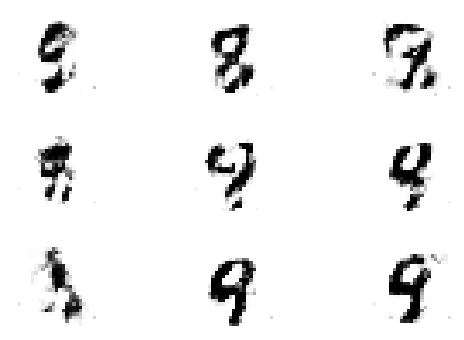

Epoch:485, D-Loss:0.358, D-Acc:95.000, G-Loss:2.748
Epoch:486, D-Loss:0.527, D-Acc:88.333, G-Loss:2.564
Epoch:487, D-Loss:0.440, D-Acc:93.333, G-Loss:2.470
Epoch:488, D-Loss:0.459, D-Acc:91.667, G-Loss:2.873
Epoch:489, D-Loss:0.458, D-Acc:88.333, G-Loss:3.059


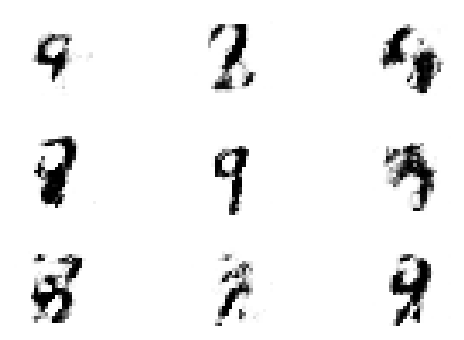

Epoch:490, D-Loss:0.741, D-Acc:83.333, G-Loss:2.757
Epoch:491, D-Loss:0.461, D-Acc:90.000, G-Loss:2.404
Epoch:492, D-Loss:0.221, D-Acc:96.667, G-Loss:3.149
Epoch:493, D-Loss:0.472, D-Acc:93.333, G-Loss:2.609
Epoch:494, D-Loss:0.375, D-Acc:93.333, G-Loss:2.286


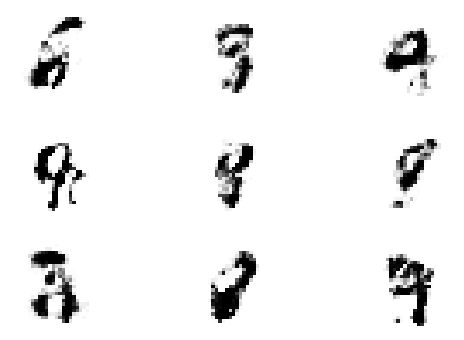

Epoch:495, D-Loss:0.485, D-Acc:88.333, G-Loss:2.706
Epoch:496, D-Loss:0.742, D-Acc:88.333, G-Loss:2.466
Epoch:497, D-Loss:0.346, D-Acc:95.000, G-Loss:2.149
Epoch:498, D-Loss:0.403, D-Acc:93.333, G-Loss:2.397
Epoch:499, D-Loss:0.811, D-Acc:83.333, G-Loss:2.746


In [7]:
# 记录损失和Wasserstein距离
losses_d = []
losses_g = []
#wasserstein_distances = []

# 训练循环
for i in range(epochs):
    if i % 5 == 0:
        show_generator_results(generator)
    
    for j in range(steps):
        # 训练判别器
        discriminator.zero_grad()
        
        # 真实样本
        real_samples = get_real_samples(batch_size//2)
        real_labels = torch.ones(batch_size//2, 1, device=device)
        real_output = discriminator(real_samples)
        d_loss_real = criterion(real_output, real_labels)

        # 假样本
        fake_samples = get_fake_samples(generator, batch_size//2)
        fake_labels = torch.zeros(batch_size//2, 1, device=device)
        fake_output = discriminator(fake_samples)
        d_loss_fake = criterion(fake_output, fake_labels)

        # 判别器总损失
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()
        
        # 计算判别器准确度
        d_acc = (torch.sum((real_output > 0.5).float()) + 
                torch.sum((fake_output < 0.5).float())) / (batch_size)

        # 训练生成器
        generator.zero_grad()
        
        #生成新的假样本
        noise = torch.randn(batch_size, 100, device=device)
        fake_samples = generator(noise)
        
        # 让判别器认为这些是真实样本
        fake_output = discriminator(fake_samples)
        g_loss = criterion(fake_output, torch.ones(batch_size, 1, device=device))

        g_loss.backward()
        optimizer_g.step()
        
        # 记录损失
        losses_d.append(d_loss.item())
        losses_g.append(g_loss.item())

    print(f"Epoch:{i}, D-Loss:{d_loss.item():.3f}, D-Acc:{d_acc.item()*100:.3f}, G-Loss:{g_loss.item():.3f}")

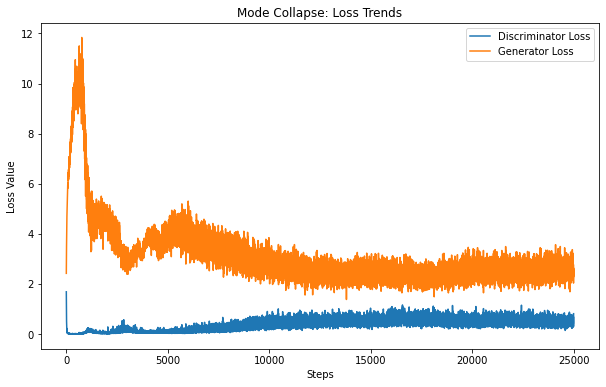

In [8]:
# 绘制损失曲线
steps = [i for i in range(len(losses_d))]
plt.figure(figsize=(10, 6))
plt.plot(losses_d)
plt.plot(losses_g)
plt.xlabel('Steps')
plt.ylabel('Loss Value')
plt.title("Mode Collapse: Loss Trends")
plt.legend(['Discriminator Loss', 'Generator Loss'])
plt.show()

# 绘制Wasserstein距离曲线
#plt.figure(figsize=(10, 6))
#plt.plot(range(0, len(wasserstein_distances)*10, 10), wasserstein_distances, label='Wasserstein Distance')
#plt.xlabel('Steps (every 10 steps)')
#plt.ylabel('Wasserstein Distance')
#plt.title("GAN Training: Wasserstein Distance")
#plt.legend()
#plt.show()